## 1. Data Cleaning & Preprocessing

In [ ]:
import pandas as pd
import numpy as np
import os
import re
from glob import glob

# Define column widths
widths = [4, 4, 3, 3, 3, 3, 7, 8, 8, 8, 8, 8, 7, 9, 6, 7, 7, 8, 8, 8, 8, 8, 8, 6, 6, 6, 7]

# Define column names
columns = [
    "Year", "Day", "Hour", "Minute", "IMF_ID", "SW_ID", "TimeShift",
    "BX", "BY", "BZ", "Speed", "Vx", "Density", "Temperature",
    "FlowPressure", "ElectricField", "PlasmaBeta",
    "Xgse", "Ygse", "Zgse", "BSN_X", "BSN_Y", "BSN_Z",
    "AE", "SYM_H", "ASY_H", "PCN"
]

# Missing value indicators
missing_values = [99.99, 999.99, 9999.99, 99999.9, 99999, 9999.99, 999999, 9999999.0]

# Folder paths
data_folder = "../Data/Omni_High_Res_Data/"
save_folder = "../Data/Omni_Cleaned_w8_NaN/"

os.makedirs(save_folder, exist_ok=True)

# Gather all files
all_files = glob(os.path.join(data_folder, "*.lst"))

# Group files by year
year_to_files = {}

for file in all_files:
    filename = os.path.basename(file)
    
    # Find 4-digit year inside filename
    match = re.search(r"(19\d{2}|20\d{2})", filename)
    if match:
        year = int(match.group(0))
        year_to_files.setdefault(year, []).append(file)
    else:
        print(f"⚠️ Warning: No year found in {filename}")

# Process each year
for year in range(1981, 2026):
    files = year_to_files.get(year, [])

    if files:
        print(f"Processing {year}...")

        year_df_list = []

        for file in files:
            df = pd.read_fwf(file, widths=widths, names=columns)

            # Replace missing values
            df.replace(missing_values, np.nan, inplace=True)

            # Create Datetime
            df['Datetime'] = pd.to_datetime(
                df['Year'].astype(str) +
                df['Day'].astype(str).str.zfill(3) +
                df['Hour'].astype(str).str.zfill(2) +
                df['Minute'].astype(str).str.zfill(2),
                format='%Y%j%H%M',
                errors='coerce'
            )

            df.set_index('Datetime', inplace=True)
            year_df_list.append(df)

        # Concatenate all months (if multiple files)
        year_df = pd.concat(year_df_list)
        year_df.sort_index(inplace=True)

        # Save
        save_path = os.path.join(save_folder, f"omni_{year}.csv")
        year_df.to_csv(save_path)
        print(f"✅ Saved cleaned data for {year} -> {save_path}")

    else:
        print(f"⚠️ Warning: No files found for {year}!")

print("🎉 All years processed successfully!")


Processing 1981...
✅ Saved cleaned data for 1981 -> ../Data/Omni_Cleaned_w8_NaN/omni_1981.csv
Processing 1982...
✅ Saved cleaned data for 1982 -> ../Data/Omni_Cleaned_w8_NaN/omni_1982.csv
Processing 1983...
✅ Saved cleaned data for 1983 -> ../Data/Omni_Cleaned_w8_NaN/omni_1983.csv
Processing 1984...
✅ Saved cleaned data for 1984 -> ../Data/Omni_Cleaned_w8_NaN/omni_1984.csv
Processing 1985...
✅ Saved cleaned data for 1985 -> ../Data/Omni_Cleaned_w8_NaN/omni_1985.csv
Processing 1986...
✅ Saved cleaned data for 1986 -> ../Data/Omni_Cleaned_w8_NaN/omni_1986.csv
Processing 1987...
✅ Saved cleaned data for 1987 -> ../Data/Omni_Cleaned_w8_NaN/omni_1987.csv
⚠️ Warning: No files found for 1988!
Processing 1989...
✅ Saved cleaned data for 1989 -> ../Data/Omni_Cleaned_w8_NaN/omni_1989.csv
Processing 1990...
✅ Saved cleaned data for 1990 -> ../Data/Omni_Cleaned_w8_NaN/omni_1990.csv
Processing 1991...
✅ Saved cleaned data for 1991 -> ../Data/Omni_Cleaned_w8_NaN/omni_1991.csv
Processing 1992...
✅ Sa

## 2. Load Cleaned Data and Plot Time Series

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import numpy as np

# ----------- Paths ----------- #
# Folder where cleaned data is saved
cleaned_folder = "../Data/Omni_Cleaned_w8_NaN/"

# Folder to save outputs
output_folder = "../Output/Omni_Plots_and_Missing/"
os.makedirs(output_folder, exist_ok=True)

# ----------- Years and Variables ----------- #
start_year = 1981
end_year = 2025

variables_to_plot = [
    "BX", "BY", "BZ", "Speed", "Vx", "Density", "Temperature",
    "FlowPressure", "ElectricField", "PlasmaBeta",
    "AE", "SYM_H", "ASY_H", "PCN"
]

# ----------- Read and Prepare Data ----------- #
all_data = []

for year in range(start_year, end_year + 1):
    file_path = os.path.join(cleaned_folder, f"omni_{year}.csv")
    year_index = pd.date_range(start=f"{year}-01-01", end=f"{year}-12-31 23:00", freq='1H')

    if os.path.exists(file_path):
        df = pd.read_csv(file_path, parse_dates=['Datetime'], index_col='Datetime')

        # 1. Select only needed variables
        df = df[variables_to_plot]

        # 2. Remove duplicate timestamps if any
        df = df[~df.index.duplicated(keep='first')]

        # 3. Reindex safely to full year (now without duplicates)
        df = df.reindex(year_index)

        all_data.append(df)

    else:
        print(f"⚠️ Warning: File not found for {year}, creating dummy NaN data.")
        dummy_df = pd.DataFrame(index=year_index, columns=variables_to_plot)
        all_data.append(dummy_df)

# ----------- Combine all years ----------- #
full_df = pd.concat(all_data)
print(f"✅ Combined all data, shape: {full_df.shape}")

# ----------- Save Missing Info ----------- #
missing_records = []

for col in variables_to_plot:
    na_mask = full_df[col].isna()
    if na_mask.any():
        timestamps = full_df.index[na_mask]
        missing_records.extend(zip(timestamps, [col]*len(timestamps)))

missing_df = pd.DataFrame(missing_records, columns=["Timestamp", "Variable"])
missing_df.sort_values(by="Timestamp", inplace=True)

missing_save_path = os.path.join(output_folder, "missing_values.csv")
missing_df.to_csv(missing_save_path, index=False)
print(f"✅ Missing info saved at: {missing_save_path}")

C:\Users\hp\AppData\Local\Temp\ipykernel_5708\995192776.py:30: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  year_index = pd.date_range(start=f"{year}-01-01", end=f"{year}-12-31 23:00", freq='1H')
C:\Users\hp\AppData\Local\Temp\ipykernel_5708\995192776.py:30: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  year_index = pd.date_range(start=f"{year}-01-01", end=f"{year}-12-31 23:00", freq='1H')
C:\Users\hp\AppData\Local\Temp\ipykernel_5708\995192776.py:30: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  year_index = pd.date_range(start=f"{year}-01-01", end=f"{year}-12-31 23:00", freq='1H')
C:\Users\hp\AppData\Local\Temp\ipykernel_5708\995192776.py:30: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  year_index = pd.date_range(start=f"{year}-01-01", end=f"{year}-12-31 23:00", freq='1

⚠️ Warning: File not found for 1988, creating dummy NaN data.


C:\Users\hp\AppData\Local\Temp\ipykernel_5708\995192776.py:30: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  year_index = pd.date_range(start=f"{year}-01-01", end=f"{year}-12-31 23:00", freq='1H')
C:\Users\hp\AppData\Local\Temp\ipykernel_5708\995192776.py:30: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  year_index = pd.date_range(start=f"{year}-01-01", end=f"{year}-12-31 23:00", freq='1H')
C:\Users\hp\AppData\Local\Temp\ipykernel_5708\995192776.py:30: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  year_index = pd.date_range(start=f"{year}-01-01", end=f"{year}-12-31 23:00", freq='1H')
C:\Users\hp\AppData\Local\Temp\ipykernel_5708\995192776.py:30: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  year_index = pd.date_range(start=f"{year}-01-01", end=f"{year}-12-31 23:00", freq='1

✅ Combined all data, shape: (394464, 14)
✅ Missing info saved at: ../Output/Omni_Plots_and_Missing/missing_values.csv


### 2.1. Plot Time Series with Gaps 


C:\Users\hp\AppData\Local\Temp\ipykernel_22956\795495891.py:25: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_22956\795495891.py:28: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(plot_save_path, dpi=300)
c:\Users\hp\Downloads\Space_Weather_Event_Analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


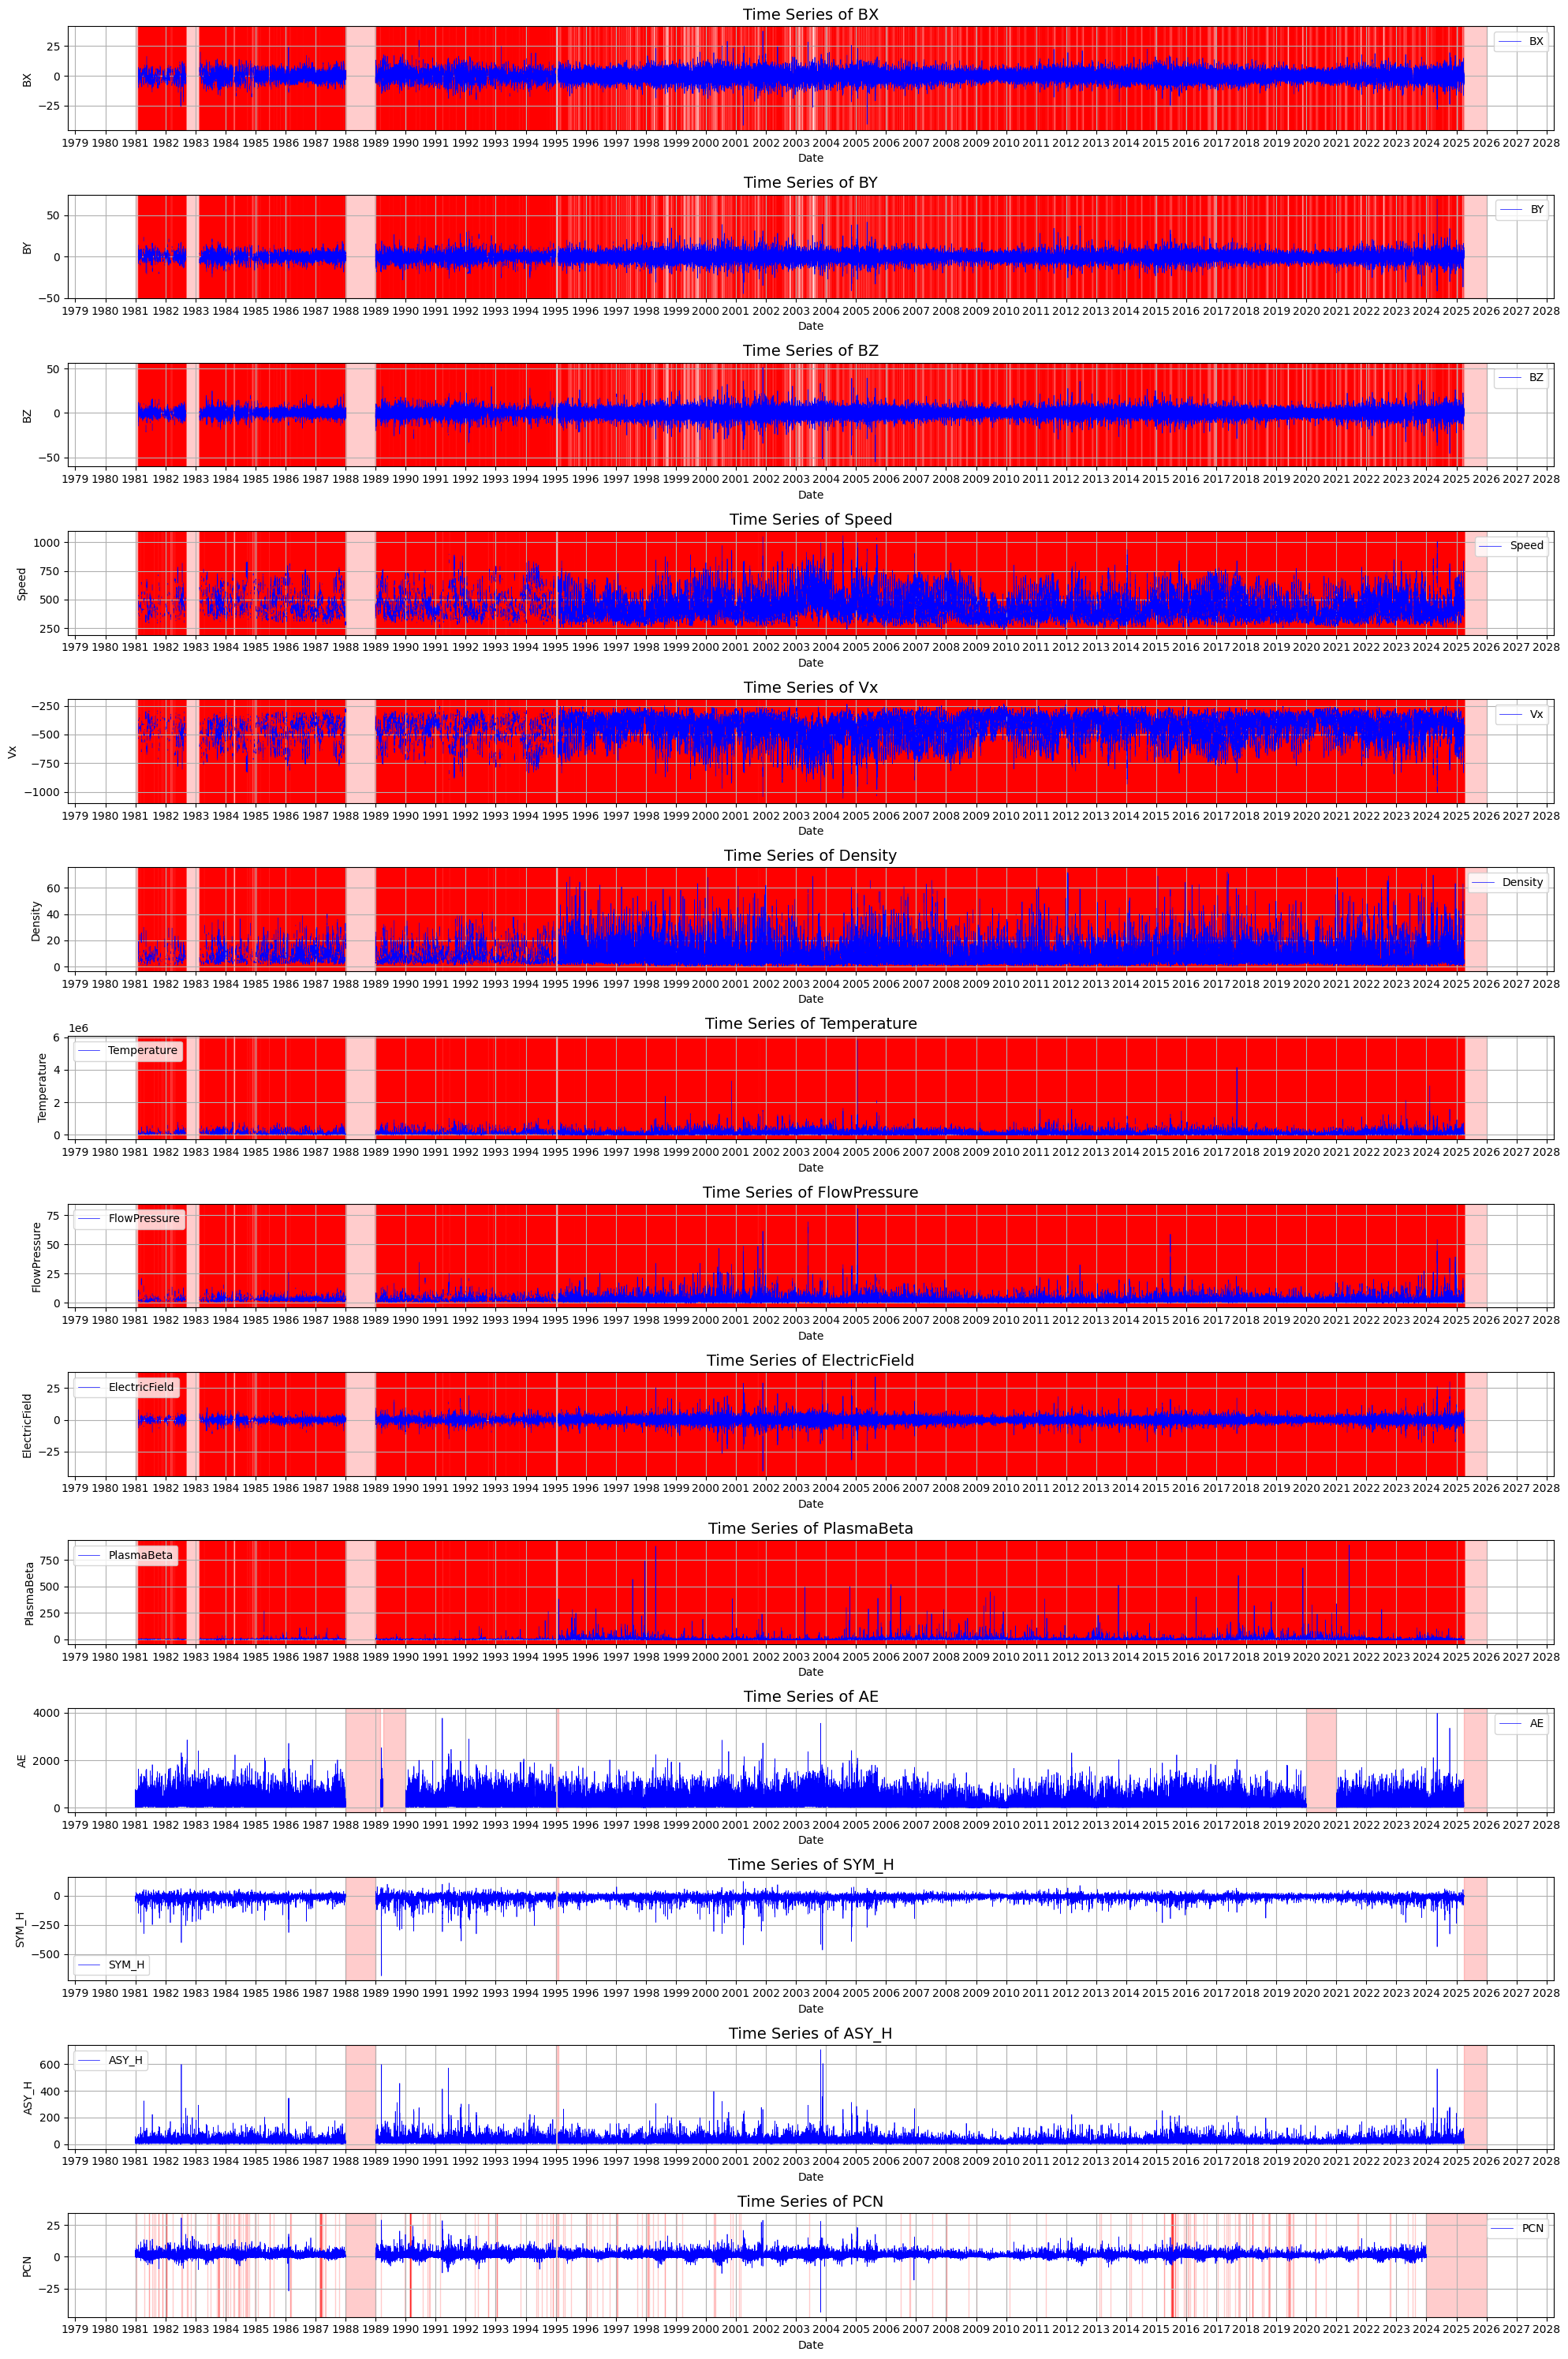

✅ Plot with gaps saved at: ../Output/Omni_Plots_and_Missing/omni_time_series_with_gaps.png


In [2]:
# ----------- Plot Time Series with Gaps ----------- #
plt.figure(figsize=(20, 30))

for i, var in enumerate(variables_to_plot, 1):
    ax = plt.subplot(len(variables_to_plot), 1, i)
    ax.plot(full_df.index, full_df[var], label=var, color='blue', linewidth=0.5)

    # Highlight NaN gaps
    na_mask = full_df[var].isna()
    if na_mask.any():
        group = (na_mask != na_mask.shift()).cumsum()
        for g in group[na_mask].unique():
            span = full_df.index[group == g]
            if len(span) > 0:
                ax.axvspan(span[0], span[-1], color='red', alpha=0.2)

    ax.set_title(f"Time Series of {var}", fontsize=14)
    ax.set_xlabel("Date")
    ax.set_ylabel(var)
    ax.grid(True)
    ax.legend()
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()

plot_save_path = os.path.join(output_folder, "omni_time_series_with_gaps.png")
plt.savefig(plot_save_path, dpi=300)
plt.show()

print(f"✅ Plot with gaps saved at: {plot_save_path}")

### 2.2. Missing % Year Wise Plot

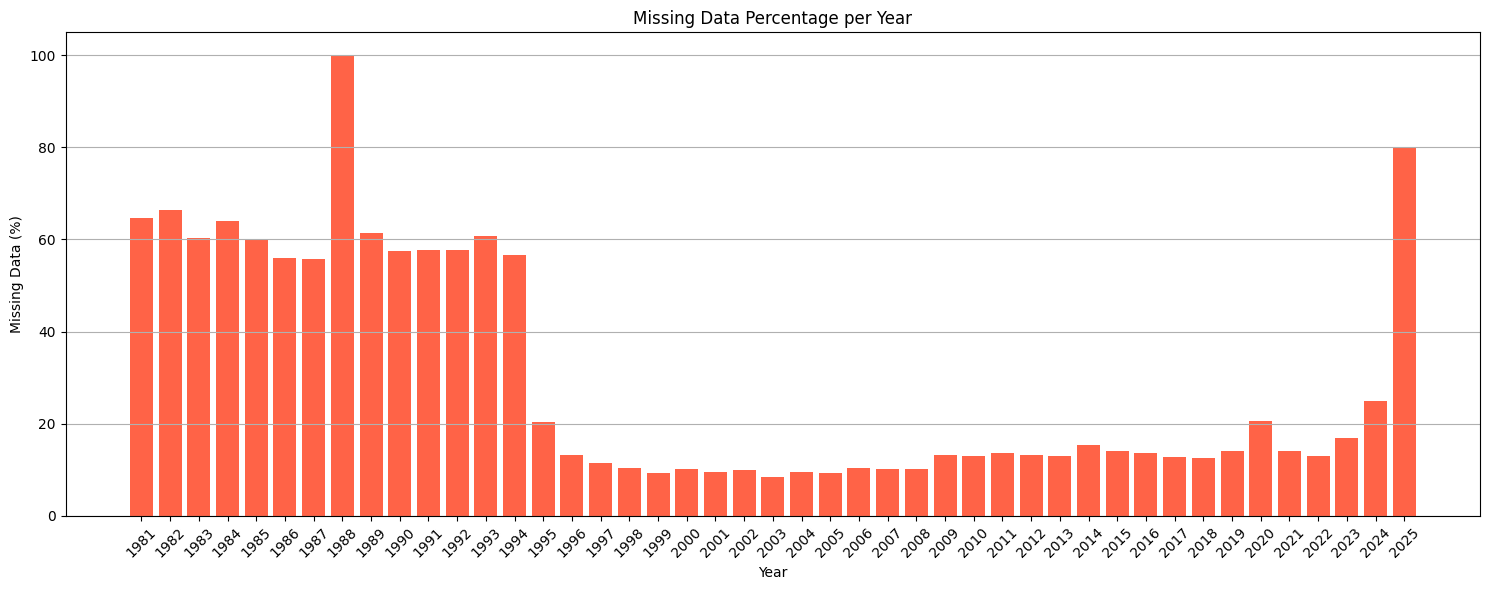

✅ Missing % per year plot saved at: ../Output/Omni_Plots_and_Missing/missing_percent_per_year.png


In [3]:
# ----------- Missing % Year Wise Plot ----------- #
missing_years = []

for year in range(start_year, end_year + 1):
    year_start = f"{year}-01-01"
    year_end = f"{year}-12-31 23:00"
    year_data = full_df.loc[year_start:year_end]

    total_points = year_data.shape[0] * len(variables_to_plot)
    missing_points = year_data.isna().sum().sum()

    missing_percent = (missing_points / total_points) * 100
    missing_years.append((year, missing_percent))

missing_years_df = pd.DataFrame(missing_years, columns=["Year", "Missing_Percent"])

# Plot missing percentage per year
plt.figure(figsize=(15, 6))
plt.bar(missing_years_df['Year'], missing_years_df['Missing_Percent'], color='tomato')
plt.xlabel('Year')
plt.ylabel('Missing Data (%)')
plt.title('Missing Data Percentage per Year')
plt.grid(axis='y')
plt.xticks(missing_years_df['Year'], rotation=45)
plt.tight_layout()

missing_percent_plot = os.path.join(output_folder, "missing_percent_per_year.png")
plt.savefig(missing_percent_plot, dpi=300)
plt.show()

print(f"✅ Missing % per year plot saved at: {missing_percent_plot}")


## Export Interactive plots

In [ ]:
################################################
import plotly.graph_objects as go
import os

# Folder to save interactive plots
output_dir = "../Output/interactive_plots/"
os.makedirs(output_dir, exist_ok=True)

for var in variables_to_plot:
    if var in full_df.columns:
        fig = go.Figure()
        fig.add_trace(go.Scatter(
            x=full_df.index,
            y=full_df[var],
            mode='lines',
            name=var
        ))
        fig.update_layout(
            title=f'{var} over Time',
            xaxis_title='Time',
            yaxis_title=var,
            template='plotly_white'
        )
        fig.write_html(f"{output_dir}/{var}_plot.html")
    else:
        print(f"Variable '{var}' not found in dataframe.")
        
###################################################

## 3. Correlation Matrix (Heatmap)

In [16]:
%matplotlib inline

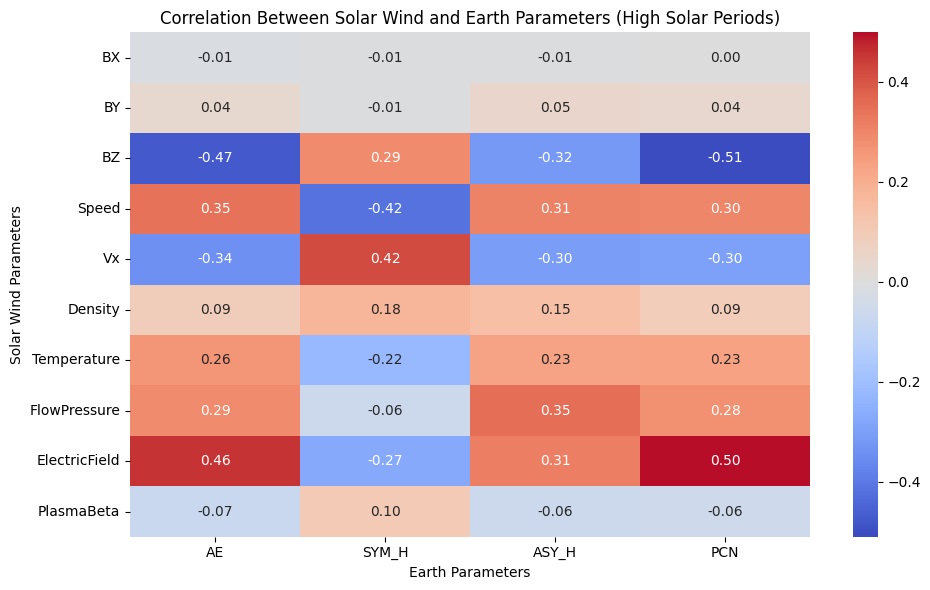

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define the ranges again (in case not in current session)
high_activity_ranges = [
    ("1987-01-01", "1991-12-31"),
    ("1998-01-01", "2002-12-31"),
    ("2012-01-01", "2016-12-31"),
    ("2023-01-01", "2025-12-31")
]

# Define variable groups
solar_wind_features = [
    "BX", "BY", "BZ", "Speed", "Vx", "Density", "Temperature",
    "FlowPressure", "ElectricField", "PlasmaBeta"
]
earth_targets = ["AE", "SYM_H", "ASY_H", "PCN"]

# Create mask to filter high activity periods
mask = pd.Series(False, index=full_df.index)
for start, end in high_activity_ranges:
    mask |= (full_df.index >= pd.to_datetime(start)) & (full_df.index <= pd.to_datetime(end))

# Filter data
df_high = full_df.loc[mask, solar_wind_features + earth_targets].dropna()

# Compute correlation between solar and earth parameters
corr_matrix = df_high.corr()
solar_vs_earth_corr = corr_matrix.loc[solar_wind_features, earth_targets]

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(solar_vs_earth_corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Between Solar Wind and Earth Parameters (High Solar Periods)")
plt.xlabel("Earth Parameters")
plt.ylabel("Solar Wind Parameters")
plt.tight_layout()
plt.show()


## 4. Distribution Plots

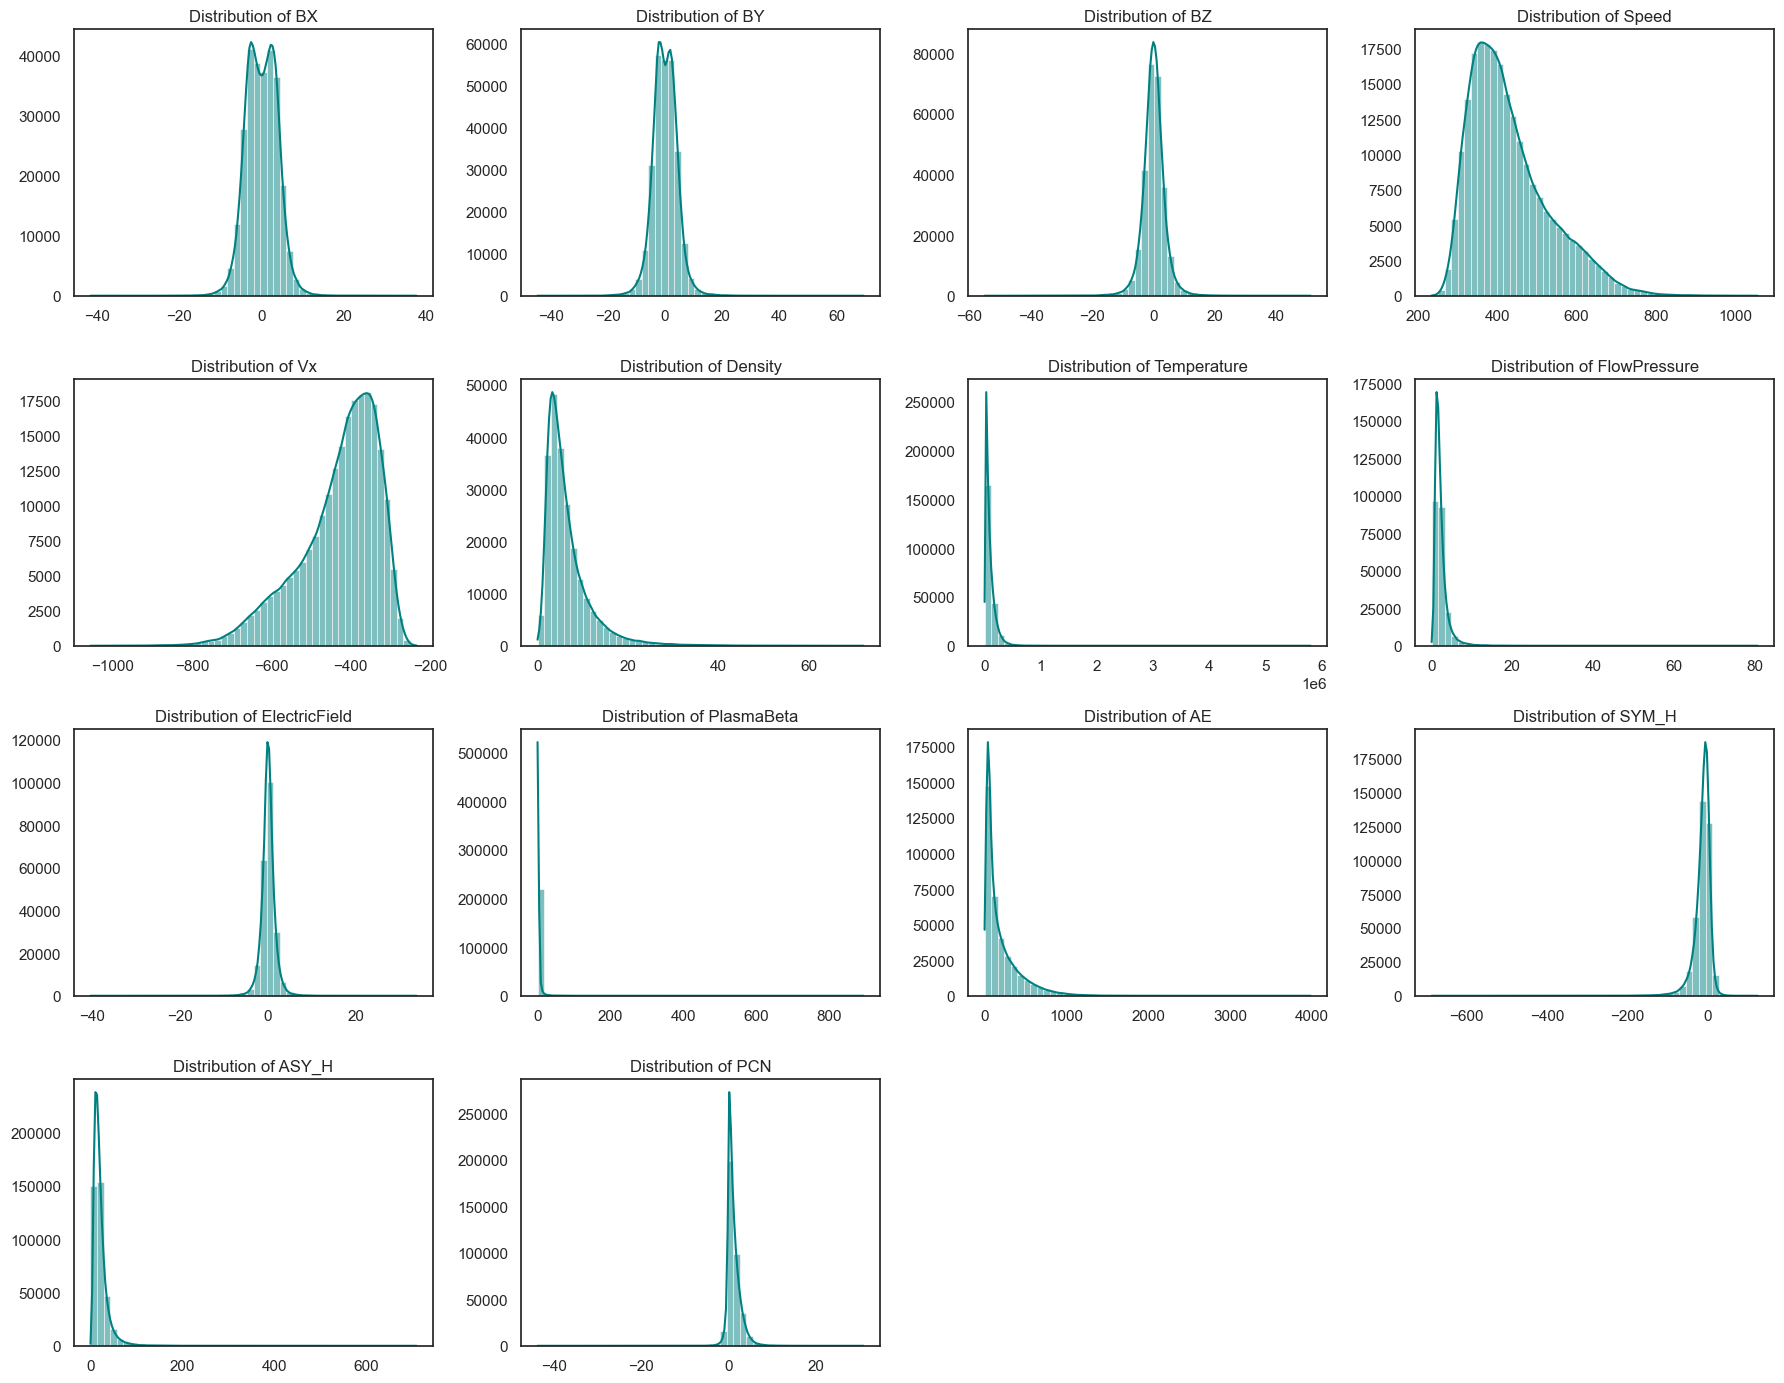

In [19]:
variables_to_plot = [
    "BX", "BY", "BZ", "Speed", "Vx", "Density", "Temperature",
    "FlowPressure", "ElectricField", "PlasmaBeta",
    "AE", "SYM_H", "ASY_H", "PCN"
]

# Plot histograms for each variable
import matplotlib.gridspec as gridspec

n = len(variables_to_plot)
cols = 4
rows = (n + cols - 1) // cols

plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(rows, cols)

for i, var in enumerate(variables_to_plot):
    ax = plt.subplot(gs[i])
    sns.histplot(full_df[var], bins=50, kde=True, ax=ax, color='teal')
    ax.set_title(f'Distribution of {var}')
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()


## 5. Plot missing Values

In [23]:
%matplotlib inline

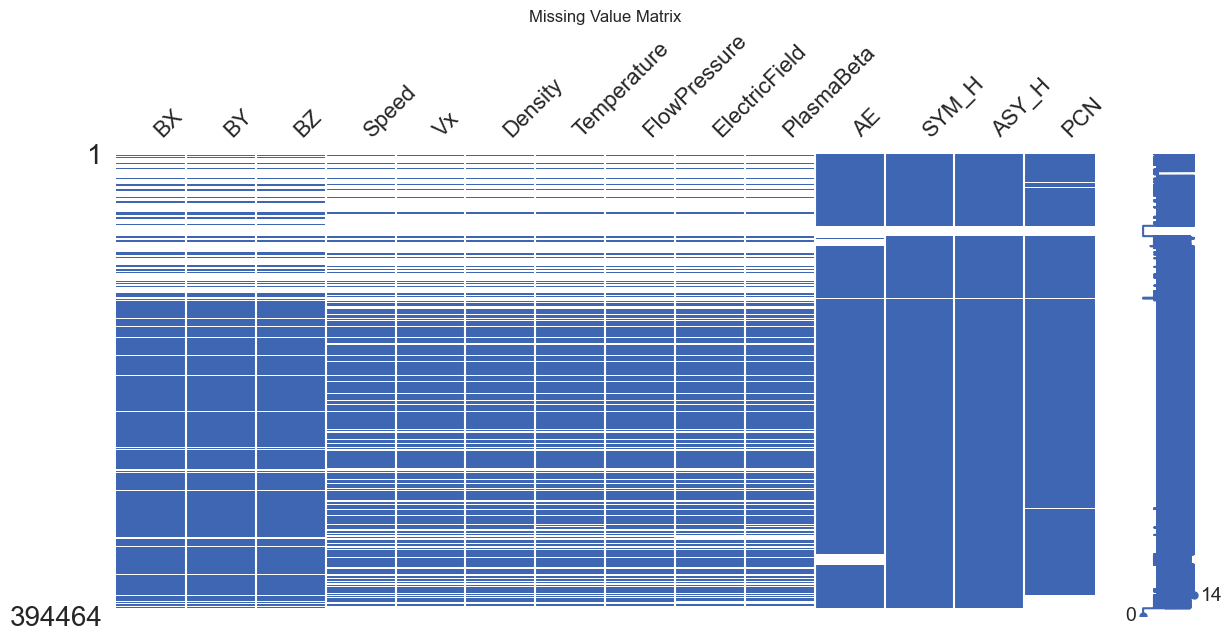

In [25]:
import missingno as msno

msno.matrix(full_df[variables_to_plot], figsize=(14, 6), color=(0.25, 0.4, 0.7))
plt.title("Missing Value Matrix")
plt.show()


## 6. Model training

### 6.1. Preprocessing and Filtering High Solar Data

In [8]:
import os
import pandas as pd
from glob import glob
from sklearn.preprocessing import MinMaxScaler

# Define feature and target variables
solar_wind_features = [
    "BX", "BY", "BZ", "Speed", "Vx", "Density", "Temperature",
    "FlowPressure", "ElectricField", "PlasmaBeta"
]
earth_targets = ["AE", "SYM_H", "ASY_H", "PCN"]

# Load all cleaned data
data_folder = "../Data/Omni_Cleaned_w8_NaN/"
csv_files = sorted(glob(os.path.join(data_folder, "omni_*.csv")))

df_list = []
for file in csv_files:
    df = pd.read_csv(file, parse_dates=["Datetime"], index_col="Datetime")
    df = df[~df.index.duplicated()]
    df = df.asfreq("H")
    df_list.append(df)

full_df = pd.concat(df_list)

# Filter only high solar activity periods
high_activity_ranges = [
    ("1987-01-01", "1991-12-31"),
    ("1998-01-01", "2002-12-31"),
    ("2012-01-01", "2016-12-31"),
    ("2023-01-01", "2025-12-31")
]

mask = pd.Series(False, index=full_df.index)
for start, end in high_activity_ranges:
    mask |= (full_df.index >= pd.to_datetime(start)) & (full_df.index <= pd.to_datetime(end))

filtered_df = full_df.loc[mask]
df_model = filtered_df[solar_wind_features + earth_targets].dropna()

X = df_model[solar_wind_features]
Y = df_model[earth_targets]

print("✅ Filtered data shape:", X.shape)
print("🕒 New date range x:", X.index.min(), "to", X.index.max())
print("🕒 New date range y:", Y.index.min(), "to", Y.index.max())


C:\Users\hp\AppData\Local\Temp\ipykernel_18704\1969300987.py:21: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.asfreq("H")
C:\Users\hp\AppData\Local\Temp\ipykernel_18704\1969300987.py:21: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.asfreq("H")
C:\Users\hp\AppData\Local\Temp\ipykernel_18704\1969300987.py:21: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.asfreq("H")
C:\Users\hp\AppData\Local\Temp\ipykernel_18704\1969300987.py:21: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.asfreq("H")
C:\Users\hp\AppData\Local\Temp\ipykernel_18704\1969300987.py:21: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.asfreq("H")
C:\Users\hp\AppData\Local\Temp\ipykernel_18704\1969300987.py:21: FutureWarn

✅ Filtered data shape: (80274, 10)
🕒 New date range x: 1987-01-02 05:00:00 to 2023-12-31 23:00:00
🕒 New date range y: 1987-01-02 05:00:00 to 2023-12-31 23:00:00


C:\Users\hp\AppData\Local\Temp\ipykernel_18704\1969300987.py:21: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.asfreq("H")


### 6.2. Scaling & Sequence Creation

In [10]:
from sklearn.utils import shuffle
import numpy as np

# Scale input and output
input_scaler = MinMaxScaler()
output_scaler = MinMaxScaler()

X_scaled = input_scaler.fit_transform(X)
Y_scaled = output_scaler.fit_transform(Y)

# Sequence generation
def create_sequences(X, Y, index, window_size=24):
    X_seq, Y_seq, times = [], [], []
    for i in range(len(X) - window_size):
        X_seq.append(X[i:i+window_size])
        Y_seq.append(Y[i+window_size])
        times.append(index[i+window_size])
    return np.array(X_seq), np.array(Y_seq), times

X_seq, Y_seq, timestamps = create_sequences(X_scaled, Y_scaled, df_model.index)

# Step 1: Group by year-month (preserving temporal structure)
df_model['YearMonth'] = df_model.index.to_period('M')

grouped_sequences = []
grouped_targets = []
grouped_times = []
window_size = 24

# Step 2: For each group, generate sequences and shuffle within the group
for _, group_df in df_model.groupby('YearMonth'):
    X_group = input_scaler.transform(group_df[solar_wind_features])
    Y_group = output_scaler.transform(group_df[earth_targets])
    idx_group = group_df.index

    if len(group_df) < window_size + 1:
        continue  # skip small groups

    # Create sequences
    X_seq_g, Y_seq_g, time_g = create_sequences(X_group, Y_group, idx_group)

    # Shuffle within this month
    X_seq_g, Y_seq_g, time_g = shuffle(X_seq_g, Y_seq_g, time_g, random_state=42)

    # Append to global list
    grouped_sequences.extend(X_seq_g)
    grouped_targets.extend(Y_seq_g)
    grouped_times.extend(time_g)

# Step 3: Convert to arrays
X_seq = np.array(grouped_sequences)
Y_seq = np.array(grouped_targets)
timestamps = np.array(grouped_times)

print("📐 Group-shuffled X_seq shape:", X_seq.shape)
print("🎯 Group-shuffled Y_seq shape:", Y_seq.shape)


📐 Group-shuffled X_seq shape: (76074, 24, 10)
🎯 Group-shuffled Y_seq shape: (76074, 4)


### 6.3. Train-Test Split

In [11]:
# Store index corresponding to the last timestamp in each sequence
window_size = 24
sequence_times = pd.to_datetime(timestamps) 

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, time_train, time_test = train_test_split(
    X_seq, Y_seq, sequence_times, test_size=0.2, shuffle=True, random_state=42
)



### 6.4. LSTM Model Training

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(Y.shape[1])
])

model.compile(optimizer='adam', loss='mse')
model.summary()

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=64,
    verbose=1
)

# Save model
model.save("../Models/earth_param_lstm_model.h5")
print("✅ Model saved as earth_param_lstm_model.h5")


c:\Users\hp\Downloads\Space_Weather_Event_Analysis\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,412 (83.64 KB)

 Trainable params: 21,412 (83.64 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
951/951 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - loss: 0.0076 - val_loss: 0.0017
Epoch 2/20
951/951 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0018 - val_loss: 0.0015
Epoch 3/20
951/951 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0015 - val_loss: 0.0014
Epoch 4/20
951/951 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0014 - val_loss: 0.0014
Epoch 5/20
951/951 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0014 - val_loss: 0.0014
Epoch 6/20
951/951 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 7/20
951/951 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 8/20
951/951 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 9/20
951/951 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 10/20
951/951 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 11/20
951/951 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 12/20
951/951 ━━━━━━━━━━━━━━━━

✅ Model saved as earth_param_lstm_model.h5


### 6.5. Plot Training & Validation Loss

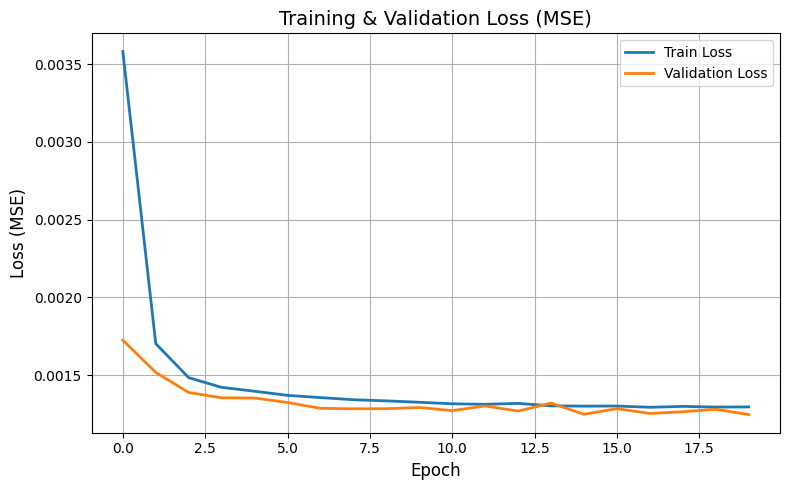

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title("Training & Validation Loss (MSE)", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss (MSE)", fontsize=12)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### 6.6. Plot MAE and RMSE for Each Target

In [14]:
output_scaler = MinMaxScaler()
Y_scaled = output_scaler.fit_transform(Y)


In [15]:
# Predict
y_pred_scaled = model.predict(X_test)
y_pred = output_scaler.inverse_transform(y_pred_scaled)
y_true = output_scaler.inverse_transform(y_test)

# Sort by actual datetime for clean plotting
sorted_indices = np.argsort(time_test)
sorted_time = time_test[sorted_indices]
y_true_sorted = y_true[sorted_indices]
y_pred_sorted = y_pred[sorted_indices]


476/476 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


📊 Earth Parameter Prediction Errors:

AE: MAE = 96.44, RMSE = 146.74
SYM_H: MAE = 8.55, RMSE = 11.83
ASY_H: MAE = 7.97, RMSE = 11.47
PCN: MAE = 0.79, RMSE = 1.15


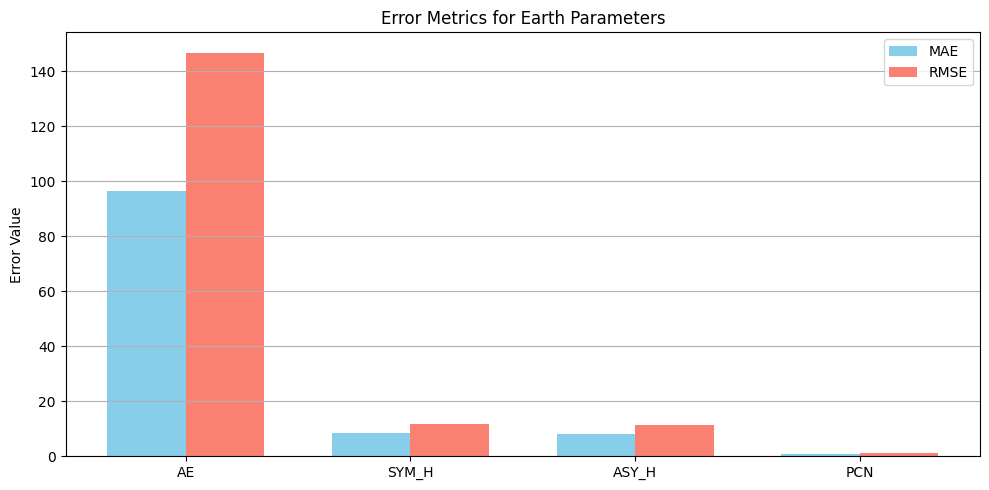

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Ensure y_true and y_pred are already defined as inverse-transformed
mae_values = []
rmse_values = []

print("📊 Earth Parameter Prediction Errors:\n")

for i, param in enumerate(earth_targets):
    mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
    mae_values.append(mae)
    rmse_values.append(rmse)
    print(f"{param}: MAE = {mae:.2f}, RMSE = {rmse:.2f}")

# 📈 Plot Bar Chart
x = np.arange(len(earth_targets))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, mae_values, width, label='MAE', color='skyblue')
plt.bar(x + width/2, rmse_values, width, label='RMSE', color='salmon')
plt.xticks(x, earth_targets)
plt.title("Error Metrics for Earth Parameters")
plt.ylabel("Error Value")
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()


### 6.7. Evaluation & Visualization

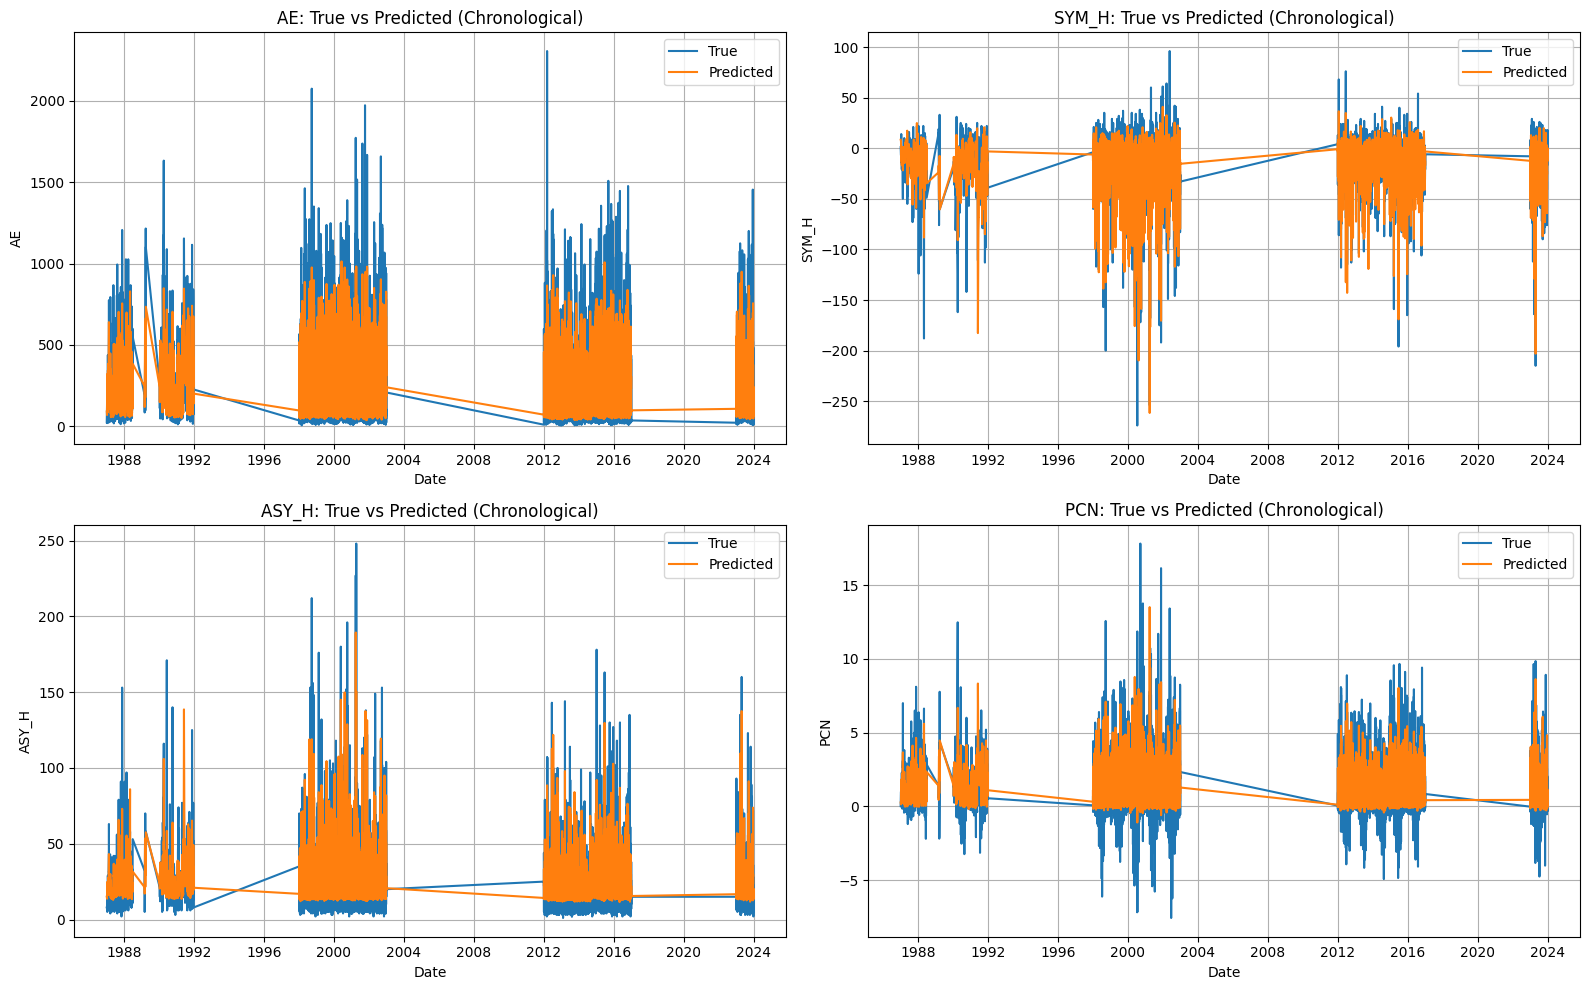

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 10))
for i, name in enumerate(earth_targets):
    plt.subplot(2, 2, i+1)
    plt.plot(sorted_time, y_true_sorted[:, i], label='True')
    plt.plot(sorted_time, y_pred_sorted[:, i], label='Predicted')
    plt.title(f"{name}: True vs Predicted (Chronological)")
    plt.xlabel("Date")
    plt.ylabel(name)
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()


### 6.8. Bias Save

In [18]:
import joblib
import json

# Save scalers
joblib.dump(input_scaler, "../Models/input_scaler.pkl")
joblib.dump(output_scaler, "../Models/output_scaler.pkl")

# Save model biases
bias_dict = {layer.name: layer.get_weights()[1].tolist()
             for layer in model.layers if len(layer.get_weights()) >= 2}

with open("../Models/lstm_model_biases.json", "w") as f:
    json.dump(bias_dict, f, indent=2)

np.savez("../Models/lstm_model_biases.npz", **{k: np.array(v) for k, v in bias_dict.items()})
print("✅ Biases and scalers saved")


✅ Biases and scalers saved


### Correlation monthly

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Group by Year-Month
df_model['YearMonth'] = df_model.index.to_period('M')  # or use: df_model.index.to_series().dt.to_period('M')

# Store per-month correlations
month_corrs = {}

# Loop through each month
for period, group in df_model.groupby('YearMonth'):
    numeric_group = group.drop(columns=["YearMonth"])
    corr = numeric_group.corr().loc[solar_wind_features, earth_targets]
    month_corrs[str(period)] = corr


print("✅ Monthly correlation matrices computed.")


✅ Monthly correlation matrices computed.


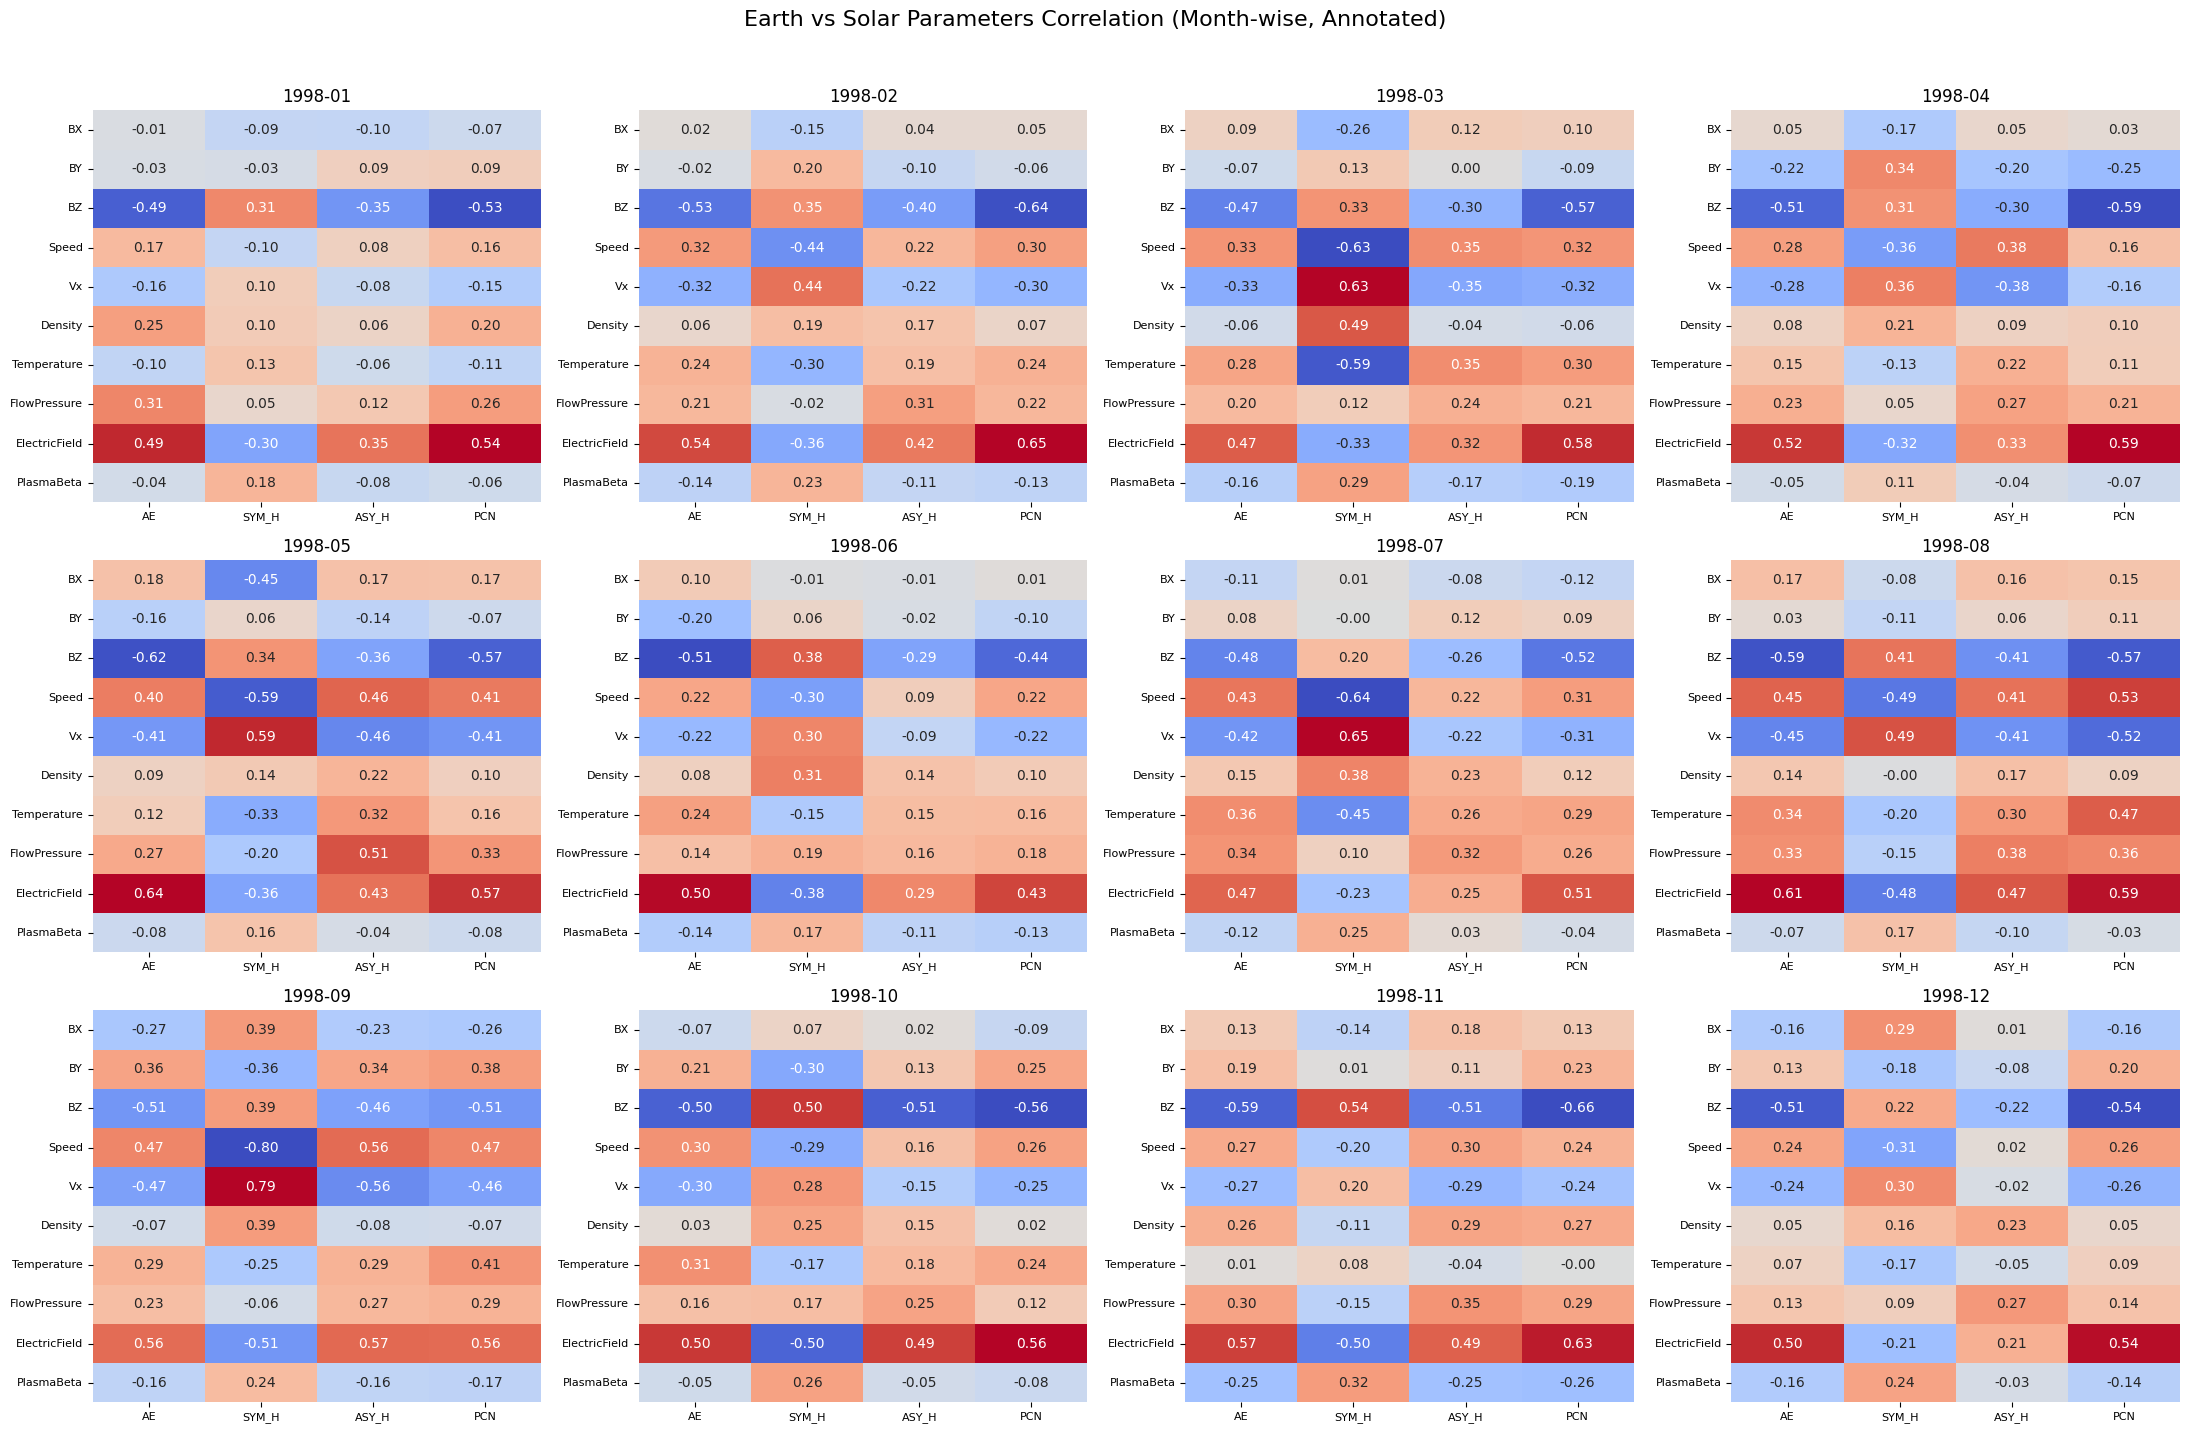

In [20]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

# Select months to plot (e.g., full year 1998)
selected_months = [k for k in month_corrs if k.startswith("1998")]

# Grid shape
cols = 4
rows = math.ceil(len(selected_months) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(22, 14))

for i, month in enumerate(selected_months):
    ax = axes[i // cols, i % cols]
    sns.heatmap(
        month_corrs[month], 
        annot=True,          # Show values
        fmt=".2f",           # Two decimal places
        cmap="coolwarm", 
        center=0, 
        ax=ax, 
        cbar=False
    )
    ax.set_title(f"{month}", fontsize=12)
    ax.tick_params(labelsize=8)

# Hide unused subplots
for j in range(i + 1, rows * cols):
    fig.delaxes(axes[j // cols, j % cols])

plt.suptitle("Earth vs Solar Parameters Correlation (Month-wise, Annotated)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()
